2552 * 3840  =  9799680  pixels


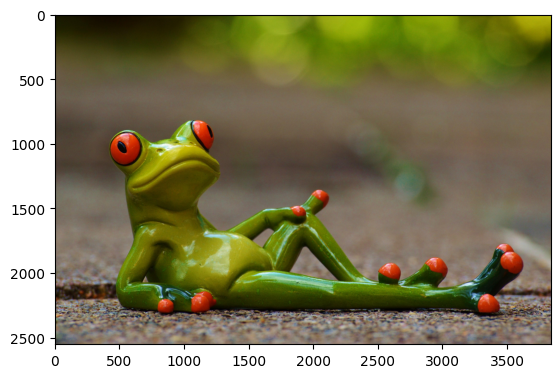

In [ ]:
from numba import cuda
from matplotlib import pyplot

img = pyplot.imread("image.jpg")

height = len(img)
width = len(img[0])
pixelCount = height*width
print(height,"*",width," = ",pixelCount," pixels")
#print(img)
pyplot.imshow(img)
pyplot.show()

duration 0.004654645919799805


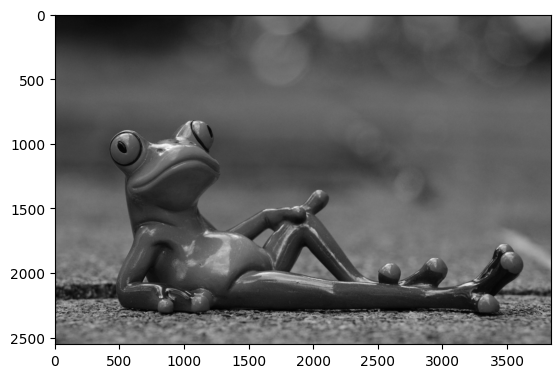

In [ ]:
import numpy as np
import time

@cuda.jit
def grayscale(src, dst):
  # where are we in the input?
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  if tidx < src.shape[0]:
    g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
    dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g

r_img = img.reshape(pixelCount, 3)
devSrc = cuda.to_device(r_img)
devDst = cuda.device_array_like(r_img)
blockSize = 128

#rounding up
gridSize = (pixelCount + blockSize - 1) // blockSize

#blank kernel call
grayscale[gridSize, blockSize](devSrc, devDst)

start=time.time()
#kernel call
grayscale[gridSize, blockSize](devSrc, devDst)
cuda.synchronize()

stop=time.time()
print("duration",stop-start)

gray_img = devDst.copy_to_host().reshape(height, width, 3)

pyplot.imshow(gray_img)
pyplot.show()

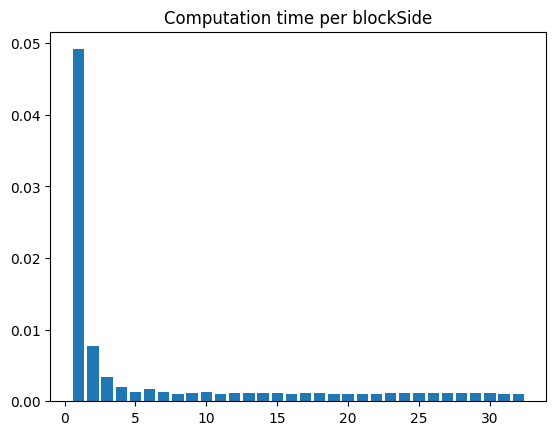

Best blockside: 8 with duration:  0.000988149642944336


'\ngray_img = devDst2.copy_to_host()\n\npyplot.imshow(gray_img)\npyplot.show()\n'

In [ ]:
@cuda.jit
def grayscale2D(src, dst):
  # where are we in the input?
  x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
  if y < src.shape[0] and x < src.shape[1]:
    g = np.uint8((src[y, x, 0] + src[y, x, 1] + src[y, x, 2]) / 3)
    dst[y, x, 0] = dst[y, x, 1] = dst[y, x, 2] = g

devSrc2 = cuda.to_device(img)
devDst2 = cuda.device_array_like(img)

#single blank kernel call with arbitrary blockSide 8
#blankGridSize2 = ((width+8-1)//8,(height+8-1)//8)
#grayscale2D[blankGridSize2, (8,8)](devSrc2, devDst2)

times = []
range_avg = 5
blockSides = range(1,33)

for blockSide in blockSides:
  avg = 0
  blockSize2 = (blockSide, blockSide)

  #rounding up
  gridSideX = (width+blockSide-1)//blockSide
  gridSideY = (height+blockSide-1)//blockSide
  gridSize2 = (gridSideX,gridSideY)

  #blank kernel call
  grayscale2D[gridSize2, blockSize2](devSrc2, devDst2)
  cuda.synchronize()

  for i in range(range_avg):
    start=time.time()

    #kernel call
    grayscale2D[gridSize2, blockSize2](devSrc2, devDst2)

    cuda.synchronize()
    stop=time.time()
    avg+=stop-start
  avg/=range_avg
  times.append(avg)

pyplot.title("Computation time per blockSide")
pyplot.bar(blockSides,times)
pyplot.show()

best_time = min(times)

print("Best blockside:", blockSides[times.index(best_time)], "with duration: ", best_time)
"""
gray_img = devDst2.copy_to_host()

pyplot.imshow(gray_img)
pyplot.show()
"""